In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import corner

events = pd.read_csv("events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

In [2]:
def quantile_list(key):
    quantiles = np.zeros(events.shape[0])
    for j in range(events.shape[0]):
    
        posterior = np.load(f"em_posteriors/source_{j}/posterior.npz")

        quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]

    return quantiles

quantiles = quantile_list("log10_mej_dyn")

In [3]:
quantiles_iota_gw = np.zeros(events.shape[0])
quantiles_dL_gw = np.zeros(events.shape[0])
quantiles_iota_em = np.zeros(events.shape[0])
quantiles_dL_em = np.zeros(events.shape[0])


for j in range(events.shape[0]):

    gw_file = f"./gw_posteriors/source_{j}/posterior_mm.npz"
    gw_posterior = dict(np.load(gw_file, allow_pickle=True))
    gw_posterior["cos_theta_jn"] = np.cos(gw_posterior["theta_jn"])
    quantiles_iota_gw[j] = np.sum(gw_posterior["cos_theta_jn"] <= np.cos(events.loc[j, "theta_jn"])) / gw_posterior["cos_theta_jn"].shape[0]
    quantiles_dL_gw[j] = np.sum(gw_posterior["luminosity_distance"] <= events.loc[j, "luminosity_distance"]) / gw_posterior["luminosity_distance"].shape[0] 
 
    
    em_file = f"./em_posteriors/source_{j}/posterior.npz"
    em_posterior = dict(np.load(em_file, allow_pickle=True))
    upside_downside = np.random.choice([-1, 1], size=(em_posterior["inclination_EM"].shape[0],))
    em_posterior["cos_theta_jn"] = upside_downside * np.cos(em_posterior["inclination_EM"])
    quantiles_iota_em[j] = np.sum(em_posterior["cos_theta_jn"] <= np.cos(events.loc[j, "theta_jn"])) / em_posterior["cos_theta_jn"].shape[0]
    quantiles_dL_em[j] = np.sum(em_posterior["luminosity_distance"] <= events.loc[j, "luminosity_distance"]) / em_posterior["luminosity_distance"].shape[0] 
 

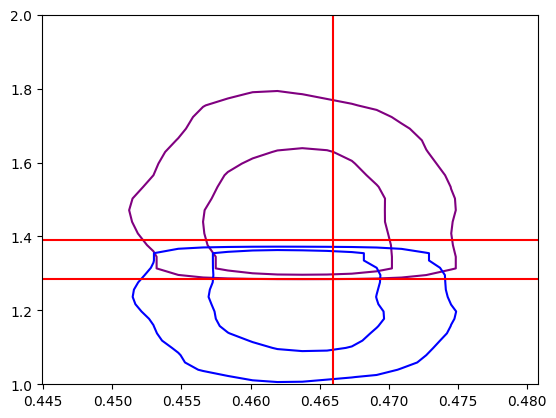

In [15]:
src = 2
gw_file = f"./gw_posteriors/source_{src}/posterior_mm.npz"
gw_posterior = np.load(gw_file)
redshift_samples = gw_posterior["mass_1"] / gw_posterior["mass_1_source"] - 1



corner.hist2d(redshift_samples, 
              gw_posterior["mass_1_source"], 
              color="purple",
              plot_density=False,
              levels=[0.68, 0.95],
              smooth=True,
              plot_datapoints=False)

corner.hist2d(redshift_samples, 
              gw_posterior["mass_2_source"], 
              color="blue",
              plot_density=False,
              levels=[0.68, 0.95],
              smooth=True,
              plot_datapoints=False)

plt.ylim((1., 2))
plt.hlines([events.loc[src, "mass_1_source"]], *plt.gca().get_xlim(), color="red")
plt.hlines([events.loc[src, "mass_2_source"]], *plt.gca().get_xlim(), color="red")
plt.vlines([events.loc[src, "redshift"]], *plt.gca().get_ylim(), color="red")

In [18]:
for src in range(26):
    gw_file = f"./gw_posteriors/source_{src}/posterior_mm.npz"
    gw_posterior = np.load(gw_file)
    redshift_samples = gw_posterior["mass_1"] / gw_posterior["mass_1_source"] - 1

    print(np.corrcoef(1/(1+redshift_samples), gw_posterior["mass_1_source"])[0,1],
          np.corrcoef(1/(1+redshift_samples), gw_posterior["mass_2_source"])[0,1])
    

0.03517732500748195 0.045342360914754104
0.05451074406974706 0.02412779499460142
0.03194680358828071 0.05840312446061377
0.022935168427906574 0.033182371814094044
0.017684386100054742 0.020446278797628597
0.05274512297068308 0.032266669867023694
0.017837878644629625 0.017938647021558396
0.006557627496389677 0.04574559314168894
0.02391815237712356 0.025050564707374507
0.0018071913157647766 0.040385392951265794
0.046539984385080876 0.044283207663364896
0.017183846341377332 0.026872728515319164
0.07647324801241656 0.011390901093687488
0.030997223842455804 0.029026128218815134
0.052210835706401094 0.013834288533379811
0.023381187901987358 0.03259680993023886
-0.006287780965322745 0.02761153628797898
0.044171065476722046 0.040345289140274965
0.026290096135304097 0.010858946341311996
0.043529445300406554 0.020365287328926583
0.044732202017467235 0.05866998339695911
0.03434743119118943 0.04472862178778265
0.032700235614895296 0.03502440075328879
0.02002977890386381 0.03279102314045889
0.02647

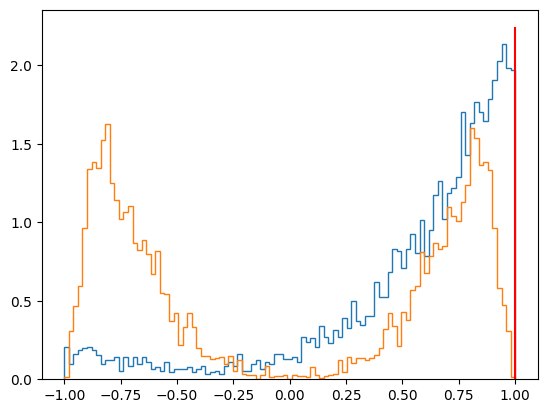

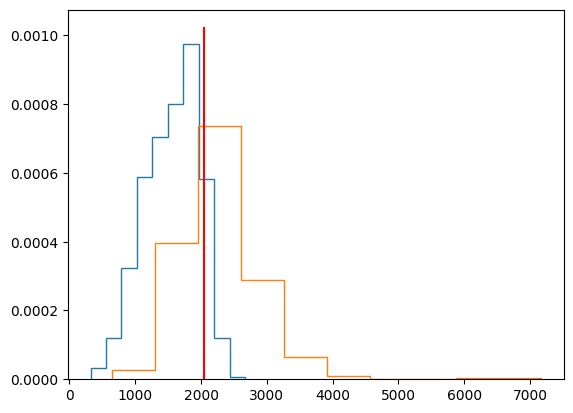

In [5]:
src = 1
gw_file = f"./gw_posteriors/source_{src}/posterior_mm.npz"
gw_posterior = dict(np.load(gw_file, allow_pickle=True))

em_file = f"./em_posteriors/source_{src}/posterior.npz"
em_posterior = dict(np.load(em_file, allow_pickle=True))

plt.hist(gw_posterior["cos_theta_jn"], histtype="step", density=True, bins = np.linspace(-1, 1, 100))
plt.hist(em_posterior["cos_theta_jn"], histtype="step", density=True, bins = np.linspace(-1, 1, 100))
plt.vlines([np.cos(events.loc[src, "theta_jn"])], *plt.gca().get_ylim(), color="red")
plt.show()

plt.hist(gw_posterior["luminosity_distance"], histtype="step", density=True)
plt.hist(em_posterior["luminosity_distance"], histtype="step", density=True)
plt.vlines([events.loc[src, "luminosity_distance"]], *plt.gca().get_ylim(), color="red")
plt.show()

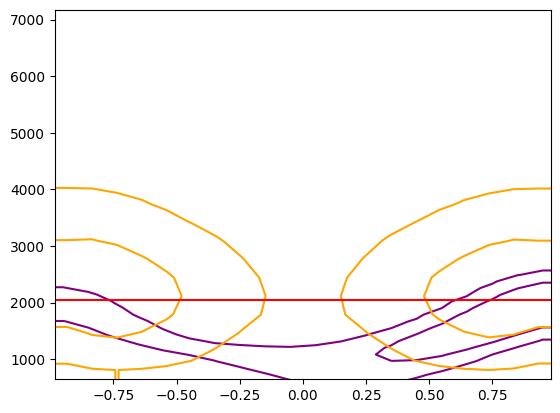

In [6]:

corner.hist2d(gw_posterior["cos_theta_jn"], 
              gw_posterior["luminosity_distance"], 
              color="purple",
              plot_density=False,
              levels=[0.68, 0.95],
              smooth=True,
              plot_datapoints=False)

corner.hist2d(em_posterior["cos_theta_jn"], 
              em_posterior["luminosity_distance"], 
              color="orange",
              plot_density=False,
              levels=[0.68, 0.95],
              smooth=True,
              plot_datapoints=False)

plt.hlines([events.loc[src, "luminosity_distance"]], *plt.gca().get_xlim(), color="red")
plt.vlines([np.cos(events.loc[src, "theta_jn"])], *plt.gca().get_ylim(), color="red")